In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../artifacts/raw/data.csv")

In [4]:
df.head()

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low


In [5]:
df.shape

(100000, 13)

In [6]:
df['Operation_Mode'].value_counts()

Operation_Mode
Active         70054
Idle           20057
Maintenance     9889
Name: count, dtype: int64

In [7]:
df.columns

Index(['Timestamp', 'Machine_ID', 'Operation_Mode', 'Temperature_C',
       'Vibration_Hz', 'Power_Consumption_kW', 'Network_Latency_ms',
       'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
       'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score',
       'Error_Rate_%', 'Efficiency_Status'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Timestamp                      100000 non-null  object 
 1   Machine_ID                     100000 non-null  int64  
 2   Operation_Mode                 100000 non-null  object 
 3   Temperature_C                  100000 non-null  float64
 4   Vibration_Hz                   100000 non-null  float64
 5   Power_Consumption_kW           100000 non-null  float64
 6   Network_Latency_ms             100000 non-null  float64
 7   Packet_Loss_%                  100000 non-null  float64
 8   Quality_Control_Defect_Rate_%  100000 non-null  float64
 9   Production_Speed_units_per_hr  100000 non-null  float64
 10  Predictive_Maintenance_Score   100000 non-null  float64
 11  Error_Rate_%                   100000 non-null  float64
 12  Efficiency_Status              

### DATA PROCESSING

In [9]:
## Handling Timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

In [10]:
df.isnull().sum()

Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
categorical_cols = ['Operation_Mode', 'Efficiency_Status']

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Timestamp                      100000 non-null  datetime64[ns]
 1   Machine_ID                     100000 non-null  int64         
 2   Operation_Mode                 100000 non-null  category      
 3   Temperature_C                  100000 non-null  float64       
 4   Vibration_Hz                   100000 non-null  float64       
 5   Power_Consumption_kW           100000 non-null  float64       
 6   Network_Latency_ms             100000 non-null  float64       
 7   Packet_Loss_%                  100000 non-null  float64       
 8   Quality_Control_Defect_Rate_%  100000 non-null  float64       
 9   Production_Speed_units_per_hr  100000 non-null  float64       
 10  Predictive_Maintenance_Score   100000 non-null  float64       
 11  E

## Exploratory Data Analysis (EDA)

In [14]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

In [15]:
numeric_cols

['Machine_ID',
 'Temperature_C',
 'Vibration_Hz',
 'Power_Consumption_kW',
 'Network_Latency_ms',
 'Packet_Loss_%',
 'Quality_Control_Defect_Rate_%',
 'Production_Speed_units_per_hr',
 'Predictive_Maintenance_Score',
 'Error_Rate_%']

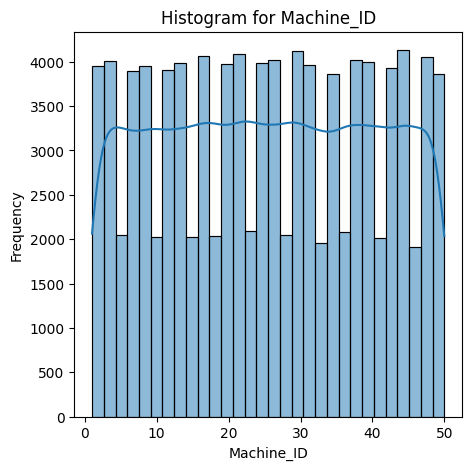

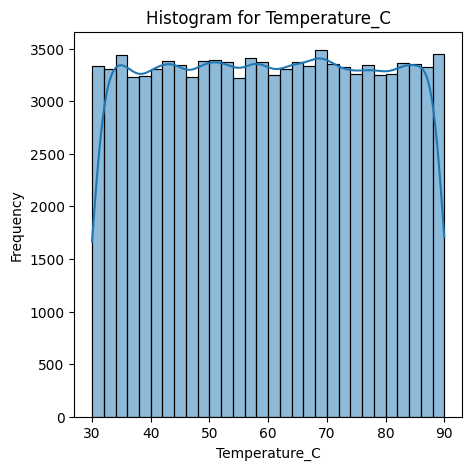

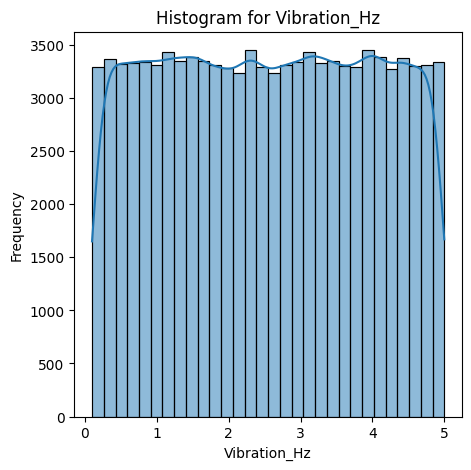

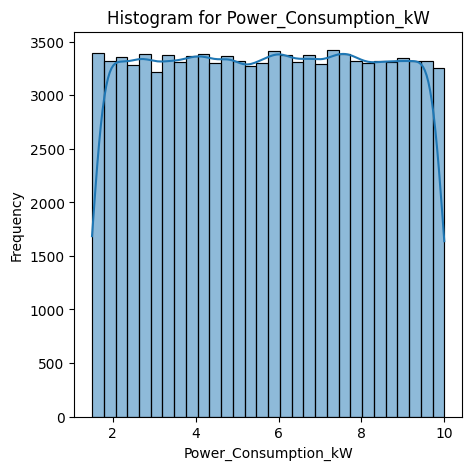

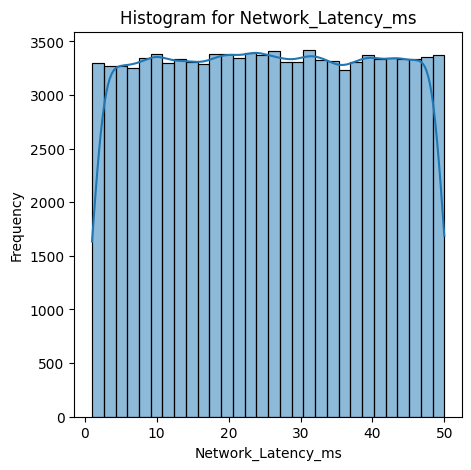

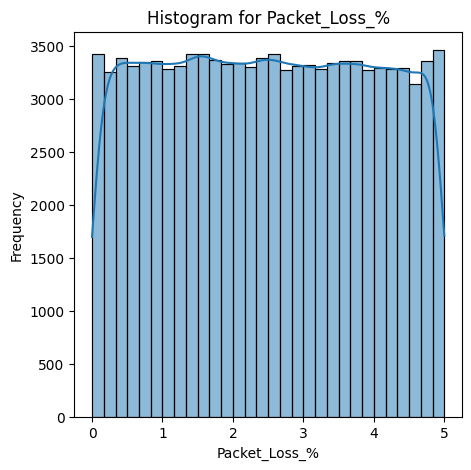

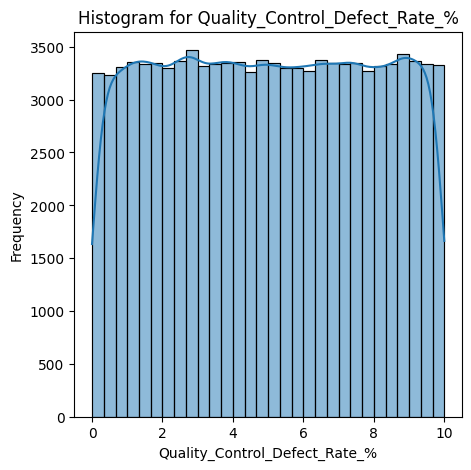

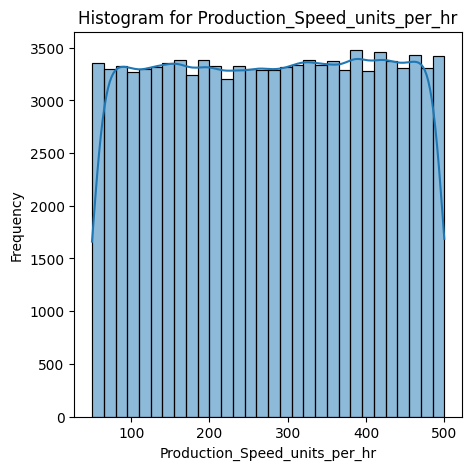

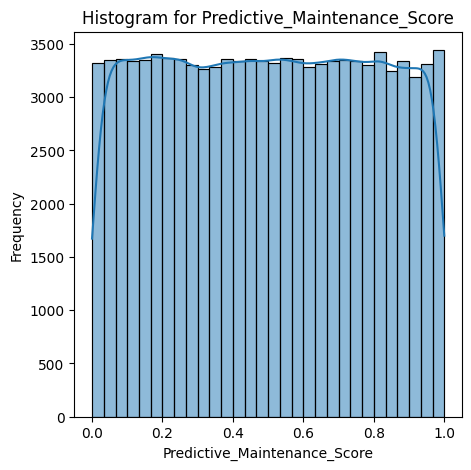

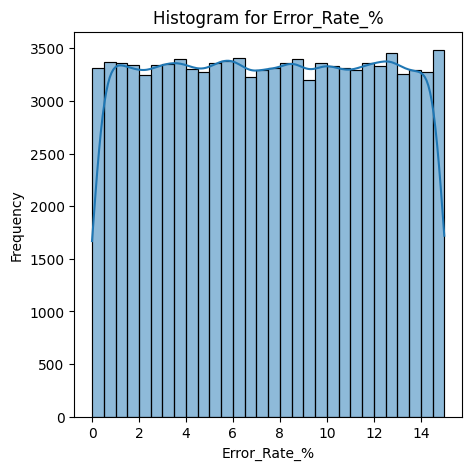

In [16]:
for col in numeric_cols:
    plt.figure(figsize = [5, 5])
    sns.histplot(df[col], kde=True, bins = 30)
    plt.title(f'Histogram for {col}', )
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

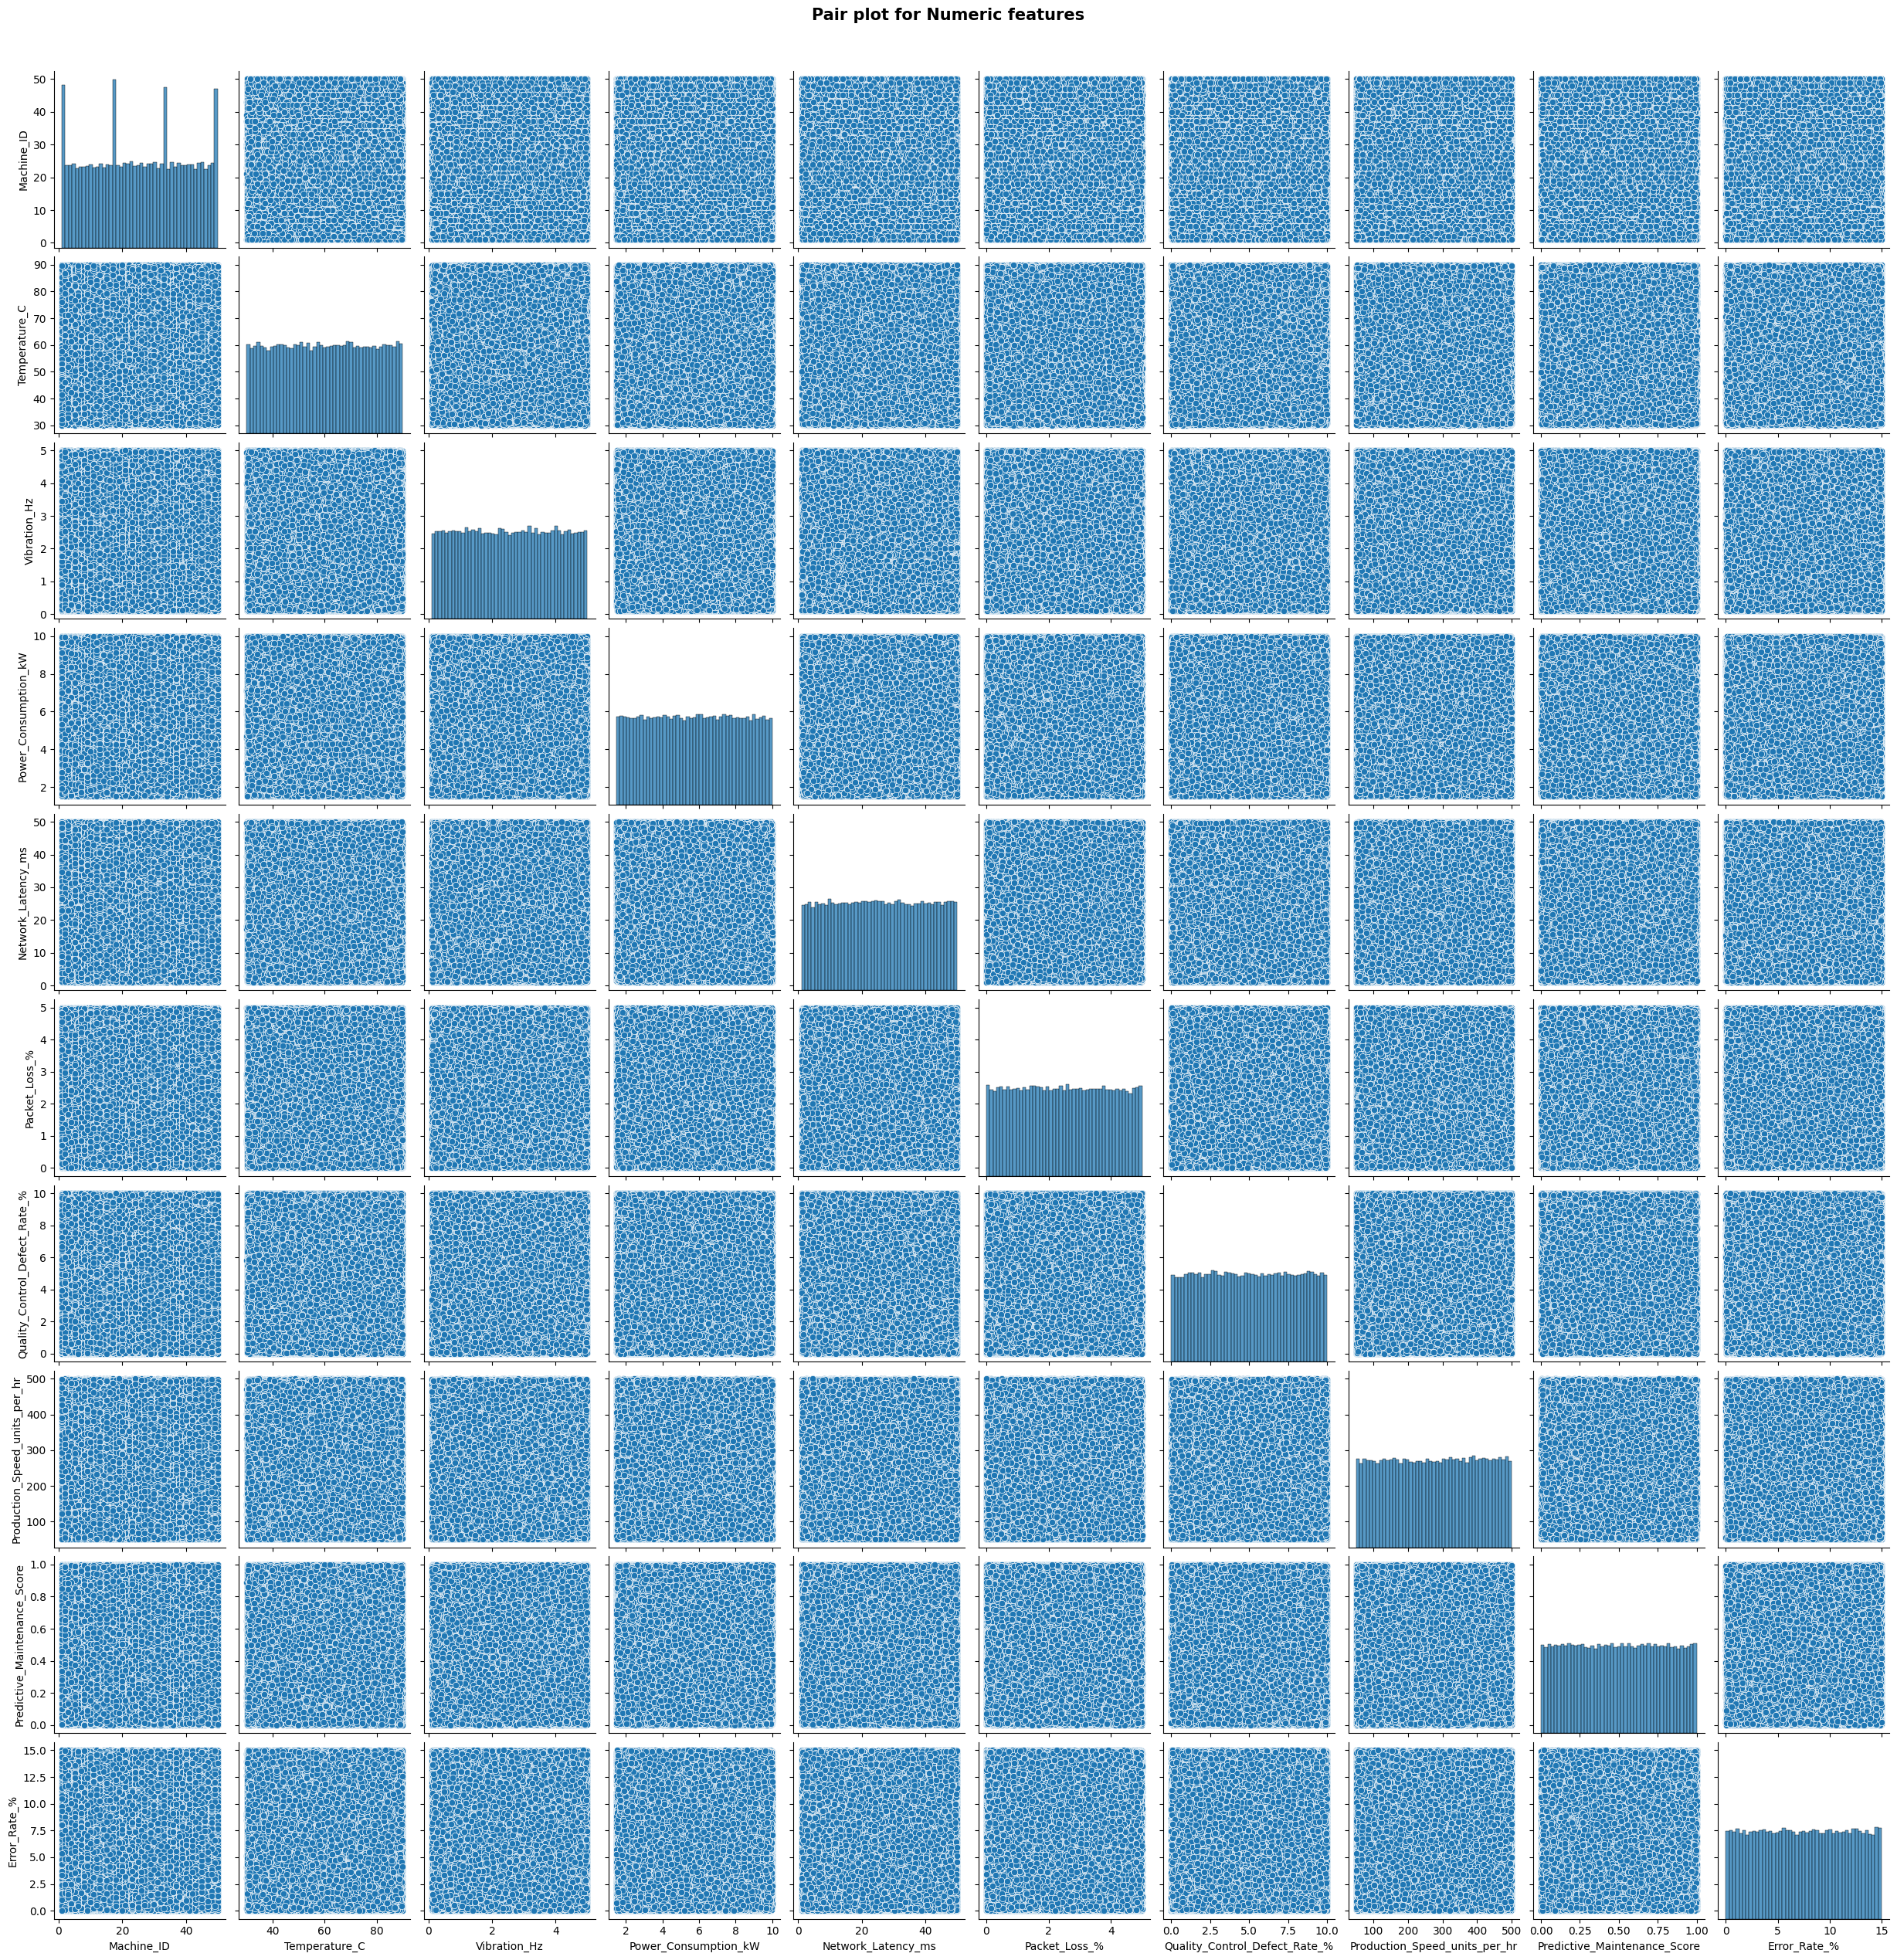

In [17]:
sns.pairplot(df[numeric_cols])
plt.suptitle('Pair plot for Numeric features', y= 1.02, fontsize=15, fontweight='bold')
plt.show()

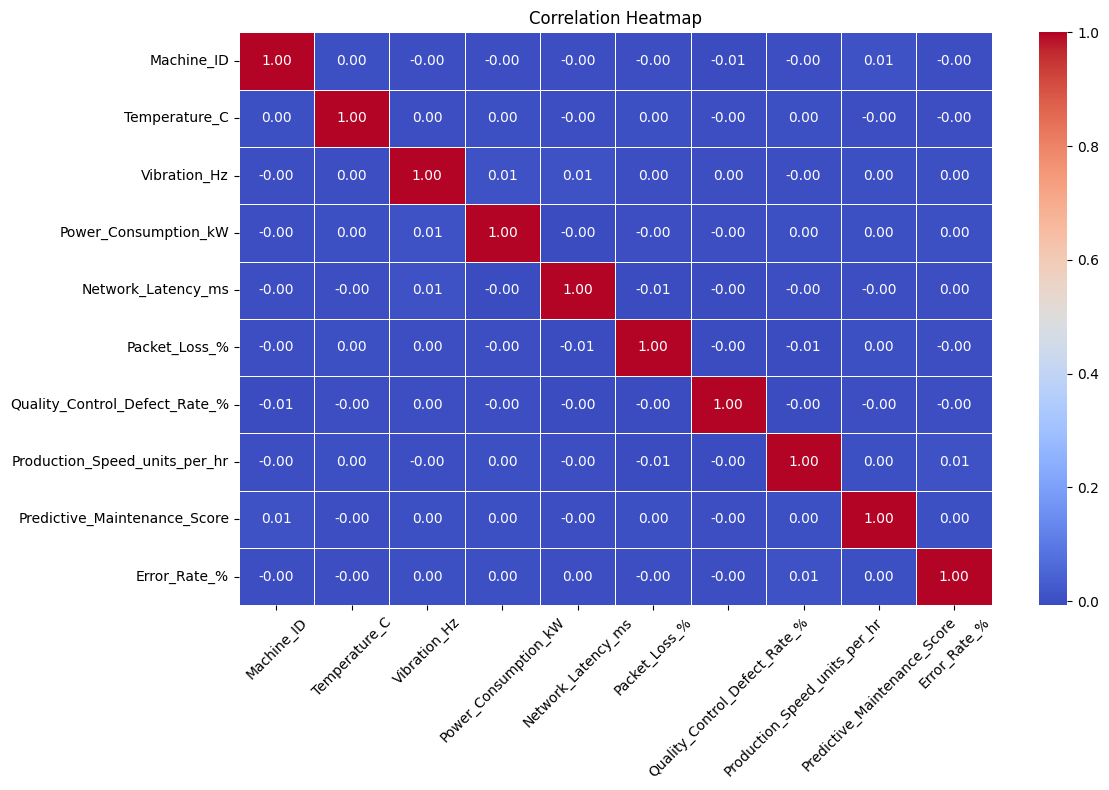

In [18]:
from IPython.core.pylabtools import figsize
plt.figure(figsize=[12, 8])
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)


plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

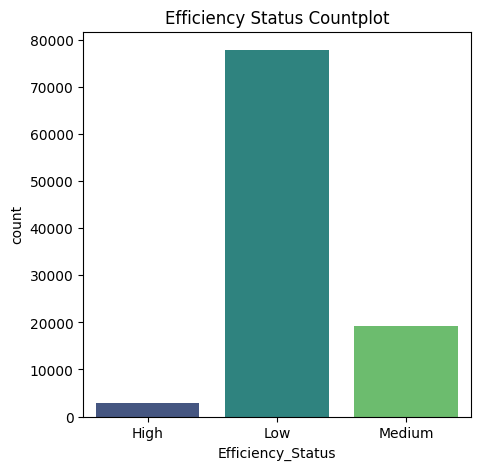

In [19]:
plt.figure(figsize=[5, 5])
sns.countplot(x = 'Efficiency_Status', data=df, palette='viridis')
plt.title("Efficiency Status Countplot")
plt.show()

### Feature Engineering 

In [20]:
df.head()

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low


In [21]:
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day

df['Hour'] = df['Timestamp'].dt.hour

In [22]:
df.drop(columns=['Timestamp', 'Machine_ID'], inplace=True)

In [23]:
df.head()

,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status,Year,Month,Day,Hour
0,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low,2024,1,1,0
1,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low,2024,1,1,0
2,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low,2024,1,1,0
3,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium,2024,1,1,0
4,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low,2024,1,1,0


In [24]:
## LabelEncoding categorical columns
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["Efficiency_Target"] = label_encoder.fit_transform(df['Efficiency_Status'])
df["Operation_Mode"] = label_encoder.fit_transform(df["Operation_Mode"])

In [25]:
## High -> 0, Low -> 1, Medium -> 2

df.head()

,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status,Year,Month,Day,Hour,Efficiency_Target
0,1,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low,2024,1,1,0,1
1,0,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low,2024,1,1,0,1
2,0,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low,2024,1,1,0,1
3,0,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium,2024,1,1,0,2
4,1,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low,2024,1,1,0,1


In [26]:
df.columns

Index(['Operation_Mode', 'Temperature_C', 'Vibration_Hz',
       'Power_Consumption_kW', 'Network_Latency_ms', 'Packet_Loss_%',
       'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
       'Predictive_Maintenance_Score', 'Error_Rate_%', 'Efficiency_Status',
       'Year', 'Month', 'Day', 'Hour', 'Efficiency_Target'],
      dtype='object')

In [27]:
features = [
    'Operation_Mode', 'Temperature_C', 'Vibration_Hz',
       'Power_Consumption_kW', 'Network_Latency_ms', 'Packet_Loss_%',
       'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
       'Predictive_Maintenance_Score', 'Error_Rate_%', 'Year', 'Month', 'Day', 'Hour'
] 

In [28]:
X = df[features]
y = df[['Efficiency_Target']]

In [29]:
X.shape, y.shape

((100000, 14), (100000, 1))

In [30]:
from sklearn.model_selection import train_test_split, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((80000, 14), (20000, 14))

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                          Feature  Importance
9                    Error_Rate_%    0.652432
7   Production_Speed_units_per_hr    0.317137
8    Predictive_Maintenance_Score    0.003595
1                   Temperature_C    0.003566
5                   Packet_Loss_%    0.003561
2                    Vibration_Hz    0.003521
3            Power_Consumption_kW    0.003454
6   Quality_Control_Defect_Rate_%    0.003432
4              Network_Latency_ms    0.003427
12                            Day    0.002376
13                           Hour    0.002302
11                          Month    0.000664
0                  Operation_Mode    0.000532
10                           Year    0.000000


# Important

### Feature importance analysis revealed that "Error Rate %" and "Production Speed units/hr" were the dominant predictors of machine efficiency. Removing these features reduced model performance from ~99% to ~77%, demonstrating their strong influence on operational efficiency prediction.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model Training

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score

In [ ]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),


    "LightGBM": LGBMClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1
    ),

}

In [55]:
import time
# RESULTS STORAGE

results = []

# ==========================================================
# TRAINING LOOP
# ==========================================================

for model_name, model in models.items():

    print(f"\n==============================")
    print(f"Training: {model_name}")
    print(f"==============================")

    # ----------------------------------------
    # TRAINING TIME
    # ----------------------------------------

    train_start = time.time()
    model.fit(X_train, y_train)
    train_end = time.time()
    training_time = train_end - train_start

    # ----------------------------------------
    # INFERENCE TIME
    # ----------------------------------------

    inference_start = time.time()
    y_pred = model.predict(X_test)
    inference_end = time.time()
    inference_time = inference_end - inference_start

    # ----------------------------------------
    # PROBABILITY PREDICTIONS
    # ----------------------------------------

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    else:
        roc_auc = np.nan

    # ----------------------------------------
    # METRICS
    # ----------------------------------------

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # ----------------------------------------
    # CROSS VALIDATION
    # ----------------------------------------

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1
    )

    cv_mean = cv_scores.mean()

    results.append({

        "Model": model_name,

        "Accuracy": round(accuracy, 4),

        "Precision": round(precision, 4),

        "Recall": round(recall, 4),

        "F1 Score": round(f1, 4),

        "ROC-AUC": round(roc_auc, 4)
        if not np.isnan(roc_auc)
        else np.nan,

        "CV Mean F1": round(cv_mean, 4),

        "Training Time (s)": round(training_time, 4),

        "Inference Time (s)": round(inference_time, 6)

})


Training: Logistic Regression

Training: Random Forest

Training: Extra Trees

Training: Gradient Boosting

Training: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002055 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2360
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 13
[LightGBM] [Info] Start training from score -3.511152
[LightGBM] [Info] Start training from score -0.250707
[LightGBM] [Info] Start training from score -1.650846
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [56]:

# RESULTS DATAFRAME
results_df = pd.DataFrame(results)

# SORT RESULTS
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

# DISPLAY RESULTS
print("\n\n================ FINAL RESULTS ================\n")

print(results_df)



================ FINAL RESULTS ================

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  \
1        Random Forest    1.0000     1.0000  1.0000    0.9999   1.0000   
3    Gradient Boosting    0.9999     0.9999  0.9999    0.9999   0.9999   
4             LightGBM    0.9986     0.9985  0.9986    0.9985   1.0000   
2          Extra Trees    0.9859     0.9859  0.9859    0.9856   0.9997   
0  Logistic Regression    0.9164     0.9149  0.9164    0.9155   0.9811   

   CV Mean F1  Training Time (s)  Inference Time (s)  
1      1.0000             2.5317            0.060597  
3      0.9999            98.6563            0.048735  
4      0.9986             0.6324            0.023528  
2      0.9846             0.9529            0.092042  
0      0.9121             0.5282            0.003762  


## Hyperparameter Tuning LightGBM and Random Forest 

In [ ]:
# OPTUNA HYPERPARAMETER TUNING - LIGHTGBM

import optuna

from lightgbm import LGBMClassifier

from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score
    

# ==========================================================
# OBJECTIVE FUNCTION
# ==========================================================

def objective_lgbm(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            15
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            200
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            100
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.5,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0
        ),

        "random_state": 42
    }

    model = LGBMClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1
    )

    return scores.mean()


# ==========================================================
# CREATE STUDY
# ==========================================================

study_lgbm = optuna.create_study(
    direction='maximize'
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=30
)

# ==========================================================
# BEST RESULTS
# ==========================================================

print("\n========== BEST LIGHTGBM PARAMETERS ==========\n")

print(study_lgbm.best_params)

print("\nBest F1 Score:\n")

print(study_lgbm.best_value)

[I 2026-05-14 04:08:35,458] A new study created in memory with name: no-name-f7955a37-6d25-4922-9ade-d0ba95014ab2
[I 2026-05-14 04:08:43,987] Trial 0 finished with value: 0.9987248963043751 and parameters: {'n_estimators': 449, 'learning_rate': 0.2996030403700609, 'max_depth': 7, 'num_leaves': 23, 'min_child_samples': 64, 'subsample': 0.8918134378847367, 'colsample_bytree': 0.7329675061926713}. Best is trial 0 with value: 0.9987248963043751.
[I 2026-05-14 04:08:52,067] Trial 1 finished with value: 0.998712718841961 and parameters: {'n_estimators': 272, 'learning_rate': 0.16867711538959532, 'max_depth': 15, 'num_leaves': 38, 'min_child_samples': 68, 'subsample': 0.6586365238734038, 'colsample_bytree': 0.7825891303163289}. Best is trial 0 with value: 0.9987248963043751.
[I 2026-05-14 04:08:59,926] Trial 2 finished with value: 0.9986627081041324 and parameters: {'n_estimators': 119, 'learning_rate': 0.2770274278126383, 'max_depth': 15, 'num_leaves': 133, 'min_child_samples': 47, 'subsampl


========== BEST LIGHTGBM PARAMETERS ==========

{'n_estimators': 221, 'learning_rate': 0.1865356889950266, 'max_depth': 4, 'num_leaves': 171, 'min_child_samples': 26, 'subsample': 0.7229257310016911, 'colsample_bytree': 0.6153911124640642}

Best F1 Score:

0.9987626572919105


In [58]:
# FINAL TUNED LIGHTGBM MODEL

best_lgbm = LGBMClassifier(
    **study_lgbm.best_params
)

best_lgbm.fit(X_train, y_train)

# Predictions
y_pred_lgbm = best_lgbm.predict(X_test)

# Final Metrics
final_f1 = f1_score(
    y_test,
    y_pred_lgbm,
    average='weighted'
)

print("\n========== FINAL TEST F1 SCORE ==========\n")

print(final_f1)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001721 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2360
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 13
[LightGBM] [Info] Start training from score -3.511152
[LightGBM] [Info] Start training from score -0.250707
[LightGBM] [Info] Start training from score -1.650846
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

In [59]:
# OPTUNA HYPERPARAMETER TUNING - RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier


def objective_rf(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            5,
            30
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            20
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2"]
        ),

        "random_state": 42,

        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1
    )

    return scores.mean()


# ==========================================================
# CREATE STUDY
# ==========================================================

study_rf = optuna.create_study(
    direction='maximize'
)

study_rf.optimize(
    objective_rf,
    n_trials=30
)

# ==========================================================
# BEST RESULTS
# ==========================================================

print("\n========== BEST RANDOM FOREST PARAMETERS ==========\n")

print(study_rf.best_params)

print("\nBest F1 Score:\n")

print(study_rf.best_value)

[I 2026-05-14 04:12:49,350] A new study created in memory with name: no-name-35e40704-fbb7-4493-a5ba-c4735eb5c10f
[I 2026-05-14 04:12:54,912] Trial 0 finished with value: 0.9999499762755765 and parameters: {'n_estimators': 127, 'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 0 with value: 0.9999499762755765.
[I 2026-05-14 04:13:05,120] Trial 1 finished with value: 0.95623433631634 and parameters: {'n_estimators': 323, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 0 with value: 0.9999499762755765.
[I 2026-05-14 04:13:16,041] Trial 2 finished with value: 0.9999374102404598 and parameters: {'n_estimators': 247, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.9999499762755765.
[I 2026-05-14 04:13:22,595] Trial 3 finished with value: 0.9999374102404598 and parameters: {'n_estimators': 143, 'max_depth': 21, 'min


========== BEST RANDOM FOREST PARAMETERS ==========

{'n_estimators': 496, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

Best F1 Score:

0.9999624770413789


In [60]:
# FINAL TUNED RANDOM FOREST MODEL

best_rf = RandomForestClassifier(
    **study_rf.best_params
)

best_rf.fit(X_train, y_train)

# Predictions
y_pred_rf = best_rf.predict(X_test)

# Final Metrics
final_f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

print("\n========== FINAL TEST F1 SCORE ==========\n")

print(final_f1_rf)


========== FINAL TEST F1 SCORE ==========

0.9999499823009063


In [61]:


print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.99855
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       597
           1       1.00      1.00      1.00     15565
           2       1.00      1.00      1.00      3838

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [64]:
## Permutation Importance

from sklearn.inspection import permutation_importance

result1 = permutation_importance(best_lgbm, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
print("RF Result:", result1)
result2 = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
print("RF Result:", result2)

RF Result: {'importances_mean': array([ 8.50000e-05, -4.50000e-05, -1.50000e-05, -9.00000e-05,
       -5.50000e-05,  9.50000e-05,  1.00000e-05,  1.73990e-01,
        1.50000e-05,  3.04835e-01,  0.00000e+00, -3.00000e-05,
        1.50000e-05,  2.50000e-05]), 'importances_std': array([5.02493781e-05, 7.22841615e-05, 1.32382023e-04, 7.34846923e-05,
       6.50000000e-05, 1.31244047e-04, 1.09087121e-04, 1.17830387e-03,
       9.50000000e-05, 1.54078714e-03, 0.00000000e+00, 2.44948974e-05,
       1.05000000e-04, 7.82623792e-05]), 'importances': array([[ 2.0000e-04,  5.0000e-05,  1.5000e-04,  5.0000e-05,  1.0000e-04,
         5.0000e-05,  5.0000e-05,  1.0000e-04,  5.0000e-05,  5.0000e-05],
       [-5.0000e-05, -1.0000e-04,  1.0000e-04, -1.0000e-04, -1.0000e-04,
         5.0000e-05, -1.5000e-04, -5.0000e-05,  0.0000e+00, -5.0000e-05],
       [ 5.0000e-05,  0.0000e+00, -2.0000e-04, -5.0000e-05, -5.0000e-05,
         2.5000e-04,  1.5000e-04, -2.0000e-04, -5.0000e-05, -5.0000e-05],
       [-5.00

In [35]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importances': result.importances_mean
})

In [37]:
importance_df.sort_values(by='Importances', ascending=False)

,Feature,Importances
9,Error_Rate_%,0.234895
7,Production_Speed_units_per_hr,0.117720
4,Network_Latency_ms,0.000235
6,Quality_Control_Defect_Rate_%,0.000150
3,Power_Consumption_kW,0.000150
13,Hour,0.000145
1,Temperature_C,0.000075
8,Predictive_Maintenance_Score,0.000015
2,Vibration_Hz,0.000005
10,Year,0.000000
